<a href="https://colab.research.google.com/github/akhil7102004-coder/TEJAS-EV/blob/main/REVIEW2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

In [8]:
df = pd.read_csv("../data/raw/TEJAS_RAW_DATA.csv")
df.head()

,Depot ID,Depot Name,District,Month,Buses Allocated,Schedules Allocated,Effective KM,Passengers,Estimated Diesel Litres,Estimated CO2 (Tonnes),Diesel Cost (INR/KM),EV Cost (INR/KM),Estimated EV Energy (MWh),Potential EV OPEX Saving (INR),EV Battery Capacity (kWh),EV Range (KM),Charging Power (kW),Electricity Tariff (INR/kWh),EV Suitability Score,Year
0,KSRTC-001,ADOOR,Pathanamthitta,2021-04,30,24,129270,163058,31679.941184,84.902242,51,27,162,3102480,250,200,120,8,0.4810,2021
1,KSRTC-001,ADOOR,Pathanamthitta,2021-05,30,24,129616,167645,31764.734714,85.129489,51,27,162,3110784,250,200,120,8,0.4895,2021
2,KSRTC-001,ADOOR,Pathanamthitta,2021-06,30,24,132462,173043,32462.198260,86.998691,51,27,166,3179088,250,200,120,8,0.4914,2021
3,KSRTC-001,ADOOR,Pathanamthitta,2021-07,31,25,140413,187995,34410.733979,92.220767,51,27,176,3369912,250,200,120,8,0.4958,2021
4,KSRTC-001,ADOOR,Pathanamthitta,2021-08,30,23,126289,162371,30949.393457,82.944374,51,27,158,3030936,250,200,120,8,0.4895,2021


In [9]:
df.shape

(5520, 20)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5520 entries, 0 to 5519
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Depot ID                        5520 non-null   object 
 1   Depot Name                      5520 non-null   object 
 2   District                        5520 non-null   object 
 3   Month                           5520 non-null   object 
 4   Buses Allocated                 5520 non-null   int64  
 5   Schedules Allocated             5520 non-null   int64  
 6   Effective KM                    5520 non-null   int64  
 7   Passengers                      5520 non-null   int64  
 8   Estimated Diesel Litres         5520 non-null   float64
 9   Estimated CO2 (Tonnes)          5520 non-null   float64
 10  Diesel Cost (INR/KM)            5520 non-null   int64  
 11  EV Cost (INR/KM)                5520 non-null   int64  
 12  Estimated EV Energy (MWh)       55

In [11]:
missing_values = df.isnull().sum()
print("Missing values in each column:")
display(missing_values.to_frame(name='Missing Values'))

Missing values in each column:


,Missing Values
Depot ID,0
Depot Name,0
District,0
Month,0
Buses Allocated,0
Schedules Allocated,0
Effective KM,0
Passengers,0
Estimated Diesel Litres,0
Estimated CO2 (Tonnes),0


In [12]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [13]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [14]:
unique_values = pd.DataFrame({
    'Column': df.columns,
    'Unique Values': [df[col].nunique() for col in df.columns]
})

display(unique_values)

,Column,Unique Values
0,Depot ID,92
1,Depot Name,92
2,District,14
3,Month,60
4,Buses Allocated,78
5,Schedules Allocated,72
6,Effective KM,5376
7,Passengers,5386
8,Estimated Diesel Litres,5376
9,Estimated CO2 (Tonnes),5376


In [15]:
constant_columns = [
    col for col in df.columns
    if df[col].nunique() <= 1
]

print("Constant columns:")
print(constant_columns)

Constant columns:
['Diesel Cost (INR/KM)', 'EV Cost (INR/KM)', 'EV Battery Capacity (kWh)', 'EV Range (KM)', 'Charging Power (kW)', 'Electricity Tariff (INR/kWh)']


In [16]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Buses Allocated,5520.0,5.196413e+01,1.559258e+01,2.700000e+01,4.000000e+01,4.900000e+01,6.400000e+01,1.050000e+02
Schedules Allocated,5520.0,4.563134e+01,1.437839e+01,2.000000e+01,3.200000e+01,4.500000e+01,5.700000e+01,9.100000e+01
Effective KM,5520.0,3.512494e+05,1.171666e+05,1.162640e+05,2.582828e+05,3.349725e+05,4.137982e+05,8.212940e+05
Passengers,5520.0,4.937929e+05,2.051798e+05,1.110050e+05,3.367790e+05,4.524280e+05,6.186890e+05,1.240216e+06
Estimated Diesel Litres,5520.0,8.607998e+04,2.871378e+04,2.849259e+04,6.329684e+04,8.209104e+04,1.014087e+05,2.012729e+05
Estimated CO2 (Tonnes),5520.0,2.306944e+02,7.695294e+01,7.636013e+01,1.696355e+02,2.200040e+02,2.717753e+02,5.394113e+02
Diesel Cost (INR/KM),5520.0,5.100000e+01,0.000000e+00,5.100000e+01,5.100000e+01,5.100000e+01,5.100000e+01,5.100000e+01
EV Cost (INR/KM),5520.0,2.700000e+01,0.000000e+00,2.700000e+01,2.700000e+01,2.700000e+01,2.700000e+01,2.700000e+01
Estimated EV Energy (MWh),5520.0,4.390853e+02,1.464608e+02,1.450000e+02,3.230000e+02,4.190000e+02,5.170000e+02,1.027000e+03
Potential EV OPEX Saving (INR),5520.0,8.429985e+06,2.811998e+06,2.790336e+06,6.198786e+06,8.039340e+06,9.931158e+06,1.971106e+07


In [17]:
df['Month'] = pd.to_datetime(df['Month'], format='%Y-%m')

print(df['Month'].min())
print(df['Month'].max())

2021-04-01 00:00:00
2026-03-01 00:00:00


In [18]:
print("Invalid Month values:", df['Month'].isna().sum())

Invalid Month values: 0


In [19]:
print("Number of unique depots:", df['Depot ID'].nunique())

Number of unique depots: 92


In [20]:
#Check negative values in numerical columns

numeric_columns = df.select_dtypes(include=np.number).columns

negative_counts = (df[numeric_columns] < 0).sum()

negative_counts = negative_counts[negative_counts > 0]

if len(negative_counts) == 0:
    print("No negative values found in numerical columns.")
else:
    print("Negative values found:")
    display(negative_counts.to_frame(name="Negative Count"))

No negative values found in numerical columns.


In [21]:
# Check zero values in numerical columns

zero_counts = (df[numeric_columns] == 0).sum()

zero_counts = zero_counts[zero_counts > 0]

if len(zero_counts) == 0:
    print("No zero values found in numerical columns.")
else:
    print("Columns containing zero values:")
    display(zero_counts.to_frame(name="Zero Count"))

No zero values found in numerical columns.


In [22]:
# Check whether each Depot ID maps consistently to one Depot Name and District

depot_consistency = df.groupby('Depot ID').agg({
    'Depot Name': 'nunique',
    'District': 'nunique'
})

print("Depot IDs with multiple Depot Names:")
display(depot_consistency[depot_consistency['Depot Name'] > 1])

print("Depot IDs with multiple Districts:")
display(depot_consistency[depot_consistency['District'] > 1])

Depot IDs with multiple Depot Names:


,Depot Name,District
Depot ID,,


Depot IDs with multiple Districts:


,Depot Name,District
Depot ID,,


In [23]:
print("Number of unique Depot IDs:", df['Depot ID'].nunique())
print("Number of unique Depot Names:", df['Depot Name'].nunique())
print("Number of unique Districts:", df['District'].nunique())

Number of unique Depot IDs: 92
Number of unique Depot Names: 92
Number of unique Districts: 14


In [24]:
#Check number of records for each depot

records_per_depot = df.groupby('Depot ID').size()

print("Minimum records per depot:", records_per_depot.min())
print("Maximum records per depot:", records_per_depot.max())

print("\nRecord-count distribution:")
display(records_per_depot.value_counts().sort_index())

Minimum records per depot: 60
Maximum records per depot: 60

Record-count distribution:


60    92
Name: count, dtype: int64

In [25]:
# Check unique months per depot

months_per_depot = df.groupby('Depot ID')['Month'].nunique()

print("Minimum unique months:", months_per_depot.min())
print("Maximum unique months:", months_per_depot.max())

print("\nDepots that do not have 60 unique months:")
display(months_per_depot[months_per_depot != 60])

Minimum unique months: 60
Maximum unique months: 60

Depots that do not have 60 unique months:


Series([], Name: Month, dtype: int64)

In [26]:
# Check whether a depot has duplicate monthly records

depot_month_duplicates = df.duplicated(
    subset=['Depot ID', 'Month']
).sum()

print("Duplicate Depot-Month records:", depot_month_duplicates)

Duplicate Depot-Month records: 0


In [27]:
# Verify Potential EV OPEX Saving

expected_saving = (
    (df['Diesel Cost (INR/KM)'] - df['EV Cost (INR/KM)'])
    * df['Effective KM']
)

difference = (
    df['Potential EV OPEX Saving (INR)'] - expected_saving
).abs()

print("Rows with incorrect Potential EV OPEX Saving:",
      (difference > 0.01).sum())

print("Maximum calculation difference:",
      difference.max())

Rows with incorrect Potential EV OPEX Saving: 0
Maximum calculation difference: 0


In [28]:
print(df.columns.tolist())

['Depot ID', 'Depot Name', 'District', 'Month', 'Buses Allocated', 'Schedules Allocated', 'Effective KM', 'Passengers', 'Estimated Diesel Litres', 'Estimated CO2 (Tonnes)', 'Diesel Cost (INR/KM)', 'EV Cost (INR/KM)', 'Estimated EV Energy (MWh)', 'Potential EV OPEX Saving (INR)', 'EV Battery Capacity (kWh)', 'EV Range (KM)', 'Charging Power (kW)', 'Electricity Tariff (INR/kWh)', 'EV Suitability Score', 'Year']


In [29]:
# Select numerical columns for outlier analysis

numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

print("Numerical columns:")
for col in numeric_columns:
    print("-", col)

Numerical columns:
- Buses Allocated
- Schedules Allocated
- Effective KM
- Passengers
- Estimated Diesel Litres
- Estimated CO2 (Tonnes)
- Diesel Cost (INR/KM)
- EV Cost (INR/KM)
- Estimated EV Energy (MWh)
- Potential EV OPEX Saving (INR)
- EV Battery Capacity (kWh)
- EV Range (KM)
- Charging Power (kW)
- Electricity Tariff (INR/kWh)
- EV Suitability Score
- Year


In [30]:
# IQR-based outlier detection

outlier_summary = []

for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)]

    outlier_summary.append({
        'Feature': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outlier Count': len(outliers),
        'Outlier %': round((len(outliers) / len(df)) * 100, 2)})

outlier_summary = pd.DataFrame(outlier_summary)

display(outlier_summary.sort_values(
    'Outlier Count',
    ascending=False))

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
14,EV Suitability Score,3.990000e-01,5.152000e-01,1.162000e-01,0.224700,6.895000e-01,271,4.91
8,Estimated EV Energy (MWh),3.230000e+02,5.170000e+02,1.940000e+02,32.000000,8.080000e+02,100,1.81
2,Effective KM,2.582828e+05,4.137982e+05,1.555155e+05,25009.500000,6.470715e+05,99,1.79
4,Estimated Diesel Litres,6.329684e+04,1.014087e+05,3.811187e+04,6129.028305,1.585765e+05,99,1.79
5,Estimated CO2 (Tonnes),1.696355e+02,2.717753e+02,1.021398e+02,16.425796,4.249851e+02,99,1.79
9,Potential EV OPEX Saving (INR),6.198786e+06,9.931158e+06,3.732372e+06,600228.000000,1.552972e+07,99,1.79
3,Passengers,3.367790e+05,6.186890e+05,2.819100e+05,-86086.000000,1.041554e+06,60,1.09
0,Buses Allocated,4.000000e+01,6.400000e+01,2.400000e+01,4.000000,1.000000e+02,20,0.36
7,EV Cost (INR/KM),2.700000e+01,2.700000e+01,0.000000e+00,27.000000,2.700000e+01,0,0.00
6,Diesel Cost (INR/KM),5.100000e+01,5.100000e+01,0.000000e+00,51.000000,5.100000e+01,0,0.00


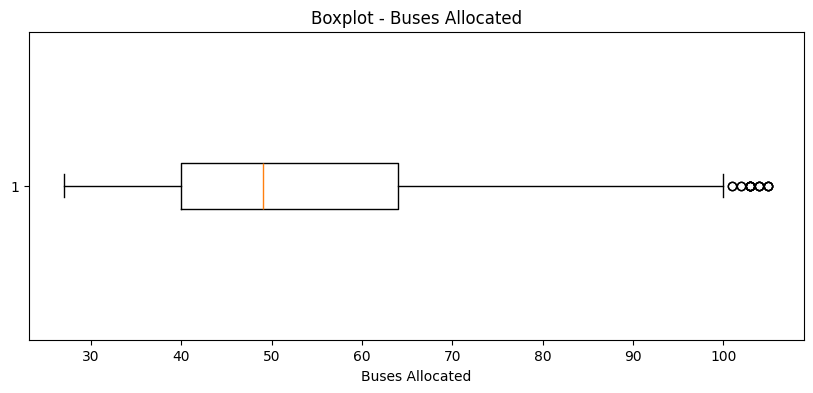

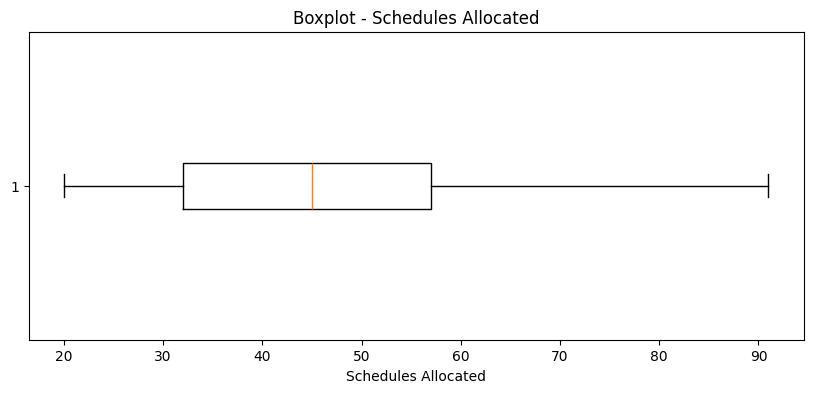

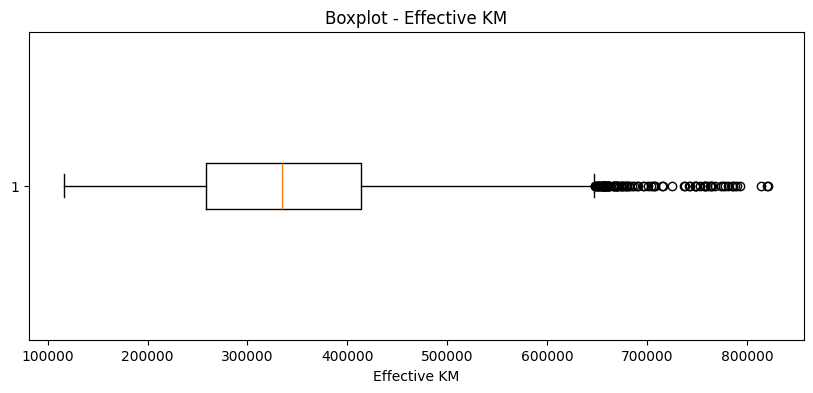

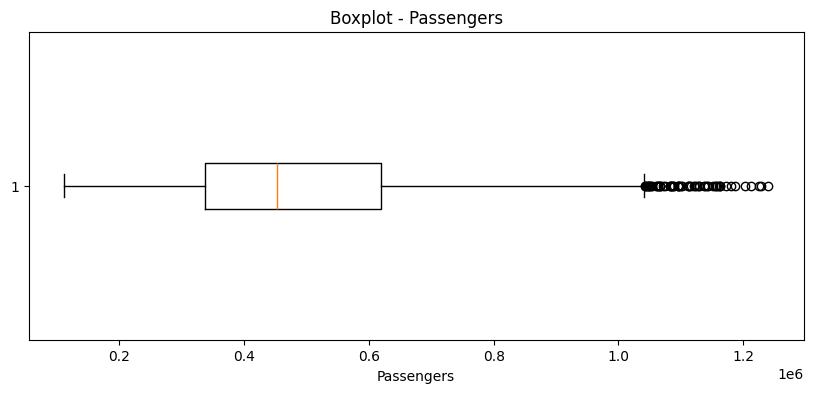

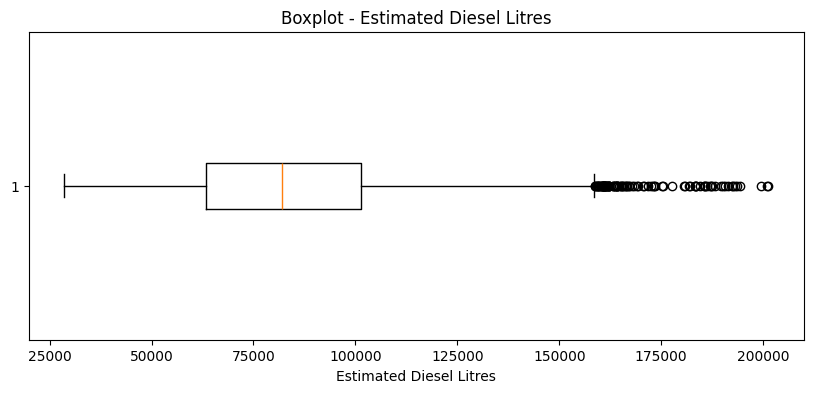

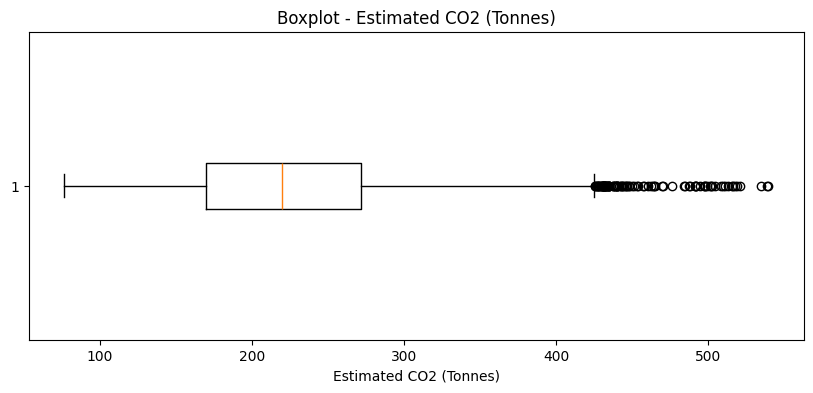

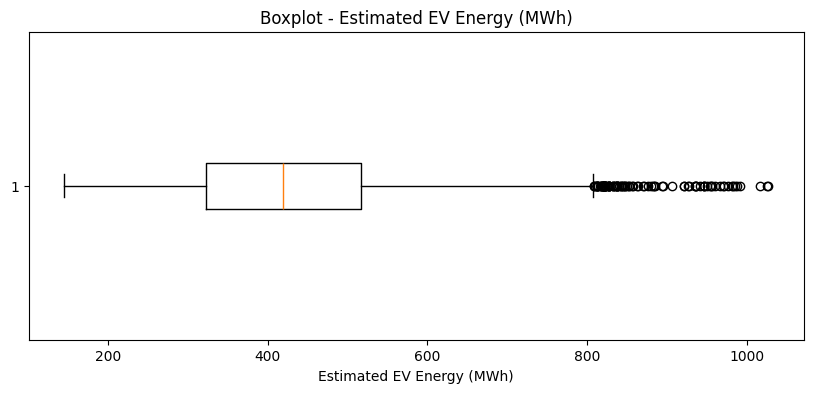

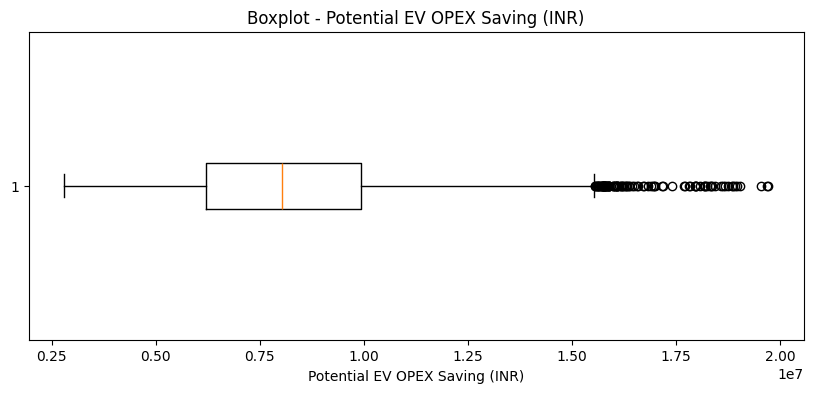

In [31]:
features_to_check = [
    'Buses Allocated',
    'Schedules Allocated',
    'Effective KM',
    'Passengers',
    'Estimated Diesel Litres',
    'Estimated CO2 (Tonnes)',
    'Estimated EV Energy (MWh)',
    'Potential EV OPEX Saving (INR)'
]

for col in features_to_check:
    plt.figure(figsize=(10, 4))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f'Boxplot - {col}')
    plt.xlabel(col)
    plt.show()

### Outlier Handling

Outliers were identified using the Interquartile Range (IQR) method.

The detected extreme values were not removed or capped because they represent legitimate operational differences between KSRTC depots, such as variations in Effective KM, passenger volume, fleet allocation, and related operational measures.

Therefore, no observations were removed solely based on IQR outlier detection. The original operational values were retained to preserve the real-world characteristics of the dataset.

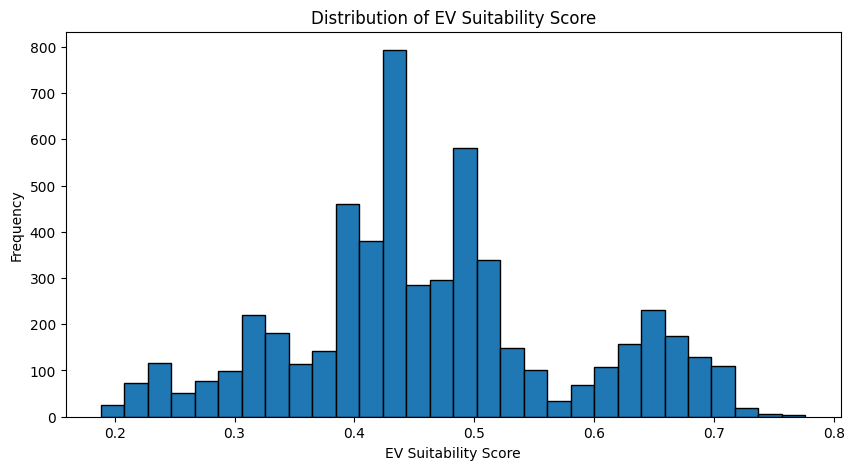

In [32]:
# Distribution of EV Suitability Score

plt.figure(figsize=(10, 5))

plt.hist(df['EV Suitability Score'],bins=30,edgecolor='black')

plt.xlabel('EV Suitability Score')
plt.ylabel('Frequency')
plt.title('Distribution of EV Suitability Score')

plt.show()

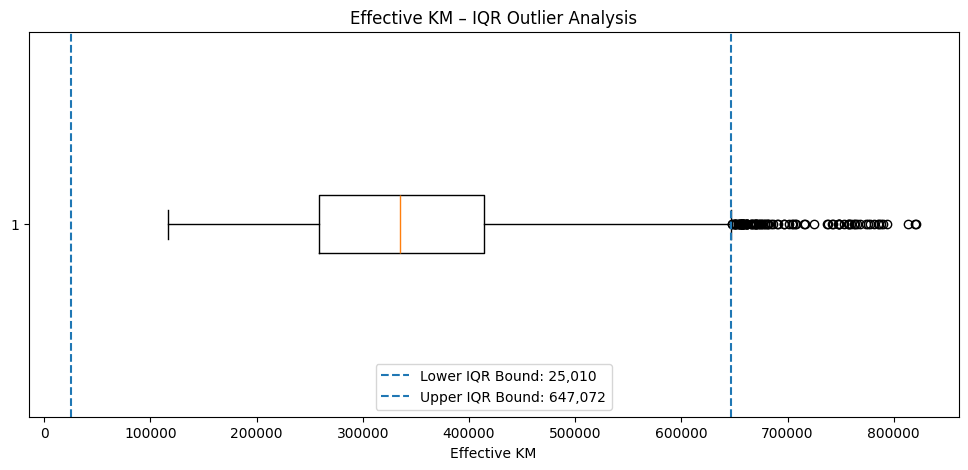

In [33]:
# Effective KM with IQR boundaries

Q1 = df['Effective KM'].quantile(0.25)
Q3 = df['Effective KM'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

plt.figure(figsize=(12, 5))

plt.boxplot(
    df['Effective KM'],
    vert=False
)

plt.axvline(
    lower_bound,
    linestyle='--',
    label=f'Lower IQR Bound: {lower_bound:,.0f}'
)

plt.axvline(
    upper_bound,
    linestyle='--',
    label=f'Upper IQR Bound: {upper_bound:,.0f}'
)

plt.xlabel('Effective KM')
plt.title('Effective KM – IQR Outlier Analysis')
plt.legend()

plt.show()

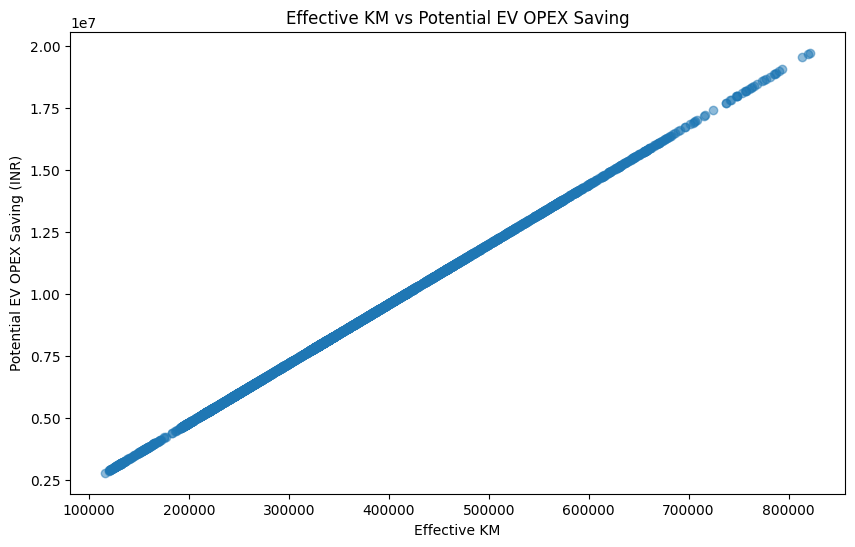

In [34]:
# Relationship between Effective KM and Potential EV OPEX Saving

plt.figure(figsize=(10, 6))

plt.scatter(
    df['Effective KM'],
    df['Potential EV OPEX Saving (INR)'],
    alpha=0.5
)

plt.xlabel('Effective KM')
plt.ylabel('Potential EV OPEX Saving (INR)')
plt.title('Effective KM vs Potential EV OPEX Saving')

plt.show()

Constant columns removed from correlation analysis:
['Diesel Cost (INR/KM)', 'EV Cost (INR/KM)', 'EV Battery Capacity (kWh)', 'EV Range (KM)', 'Charging Power (kW)', 'Electricity Tariff (INR/kWh)']


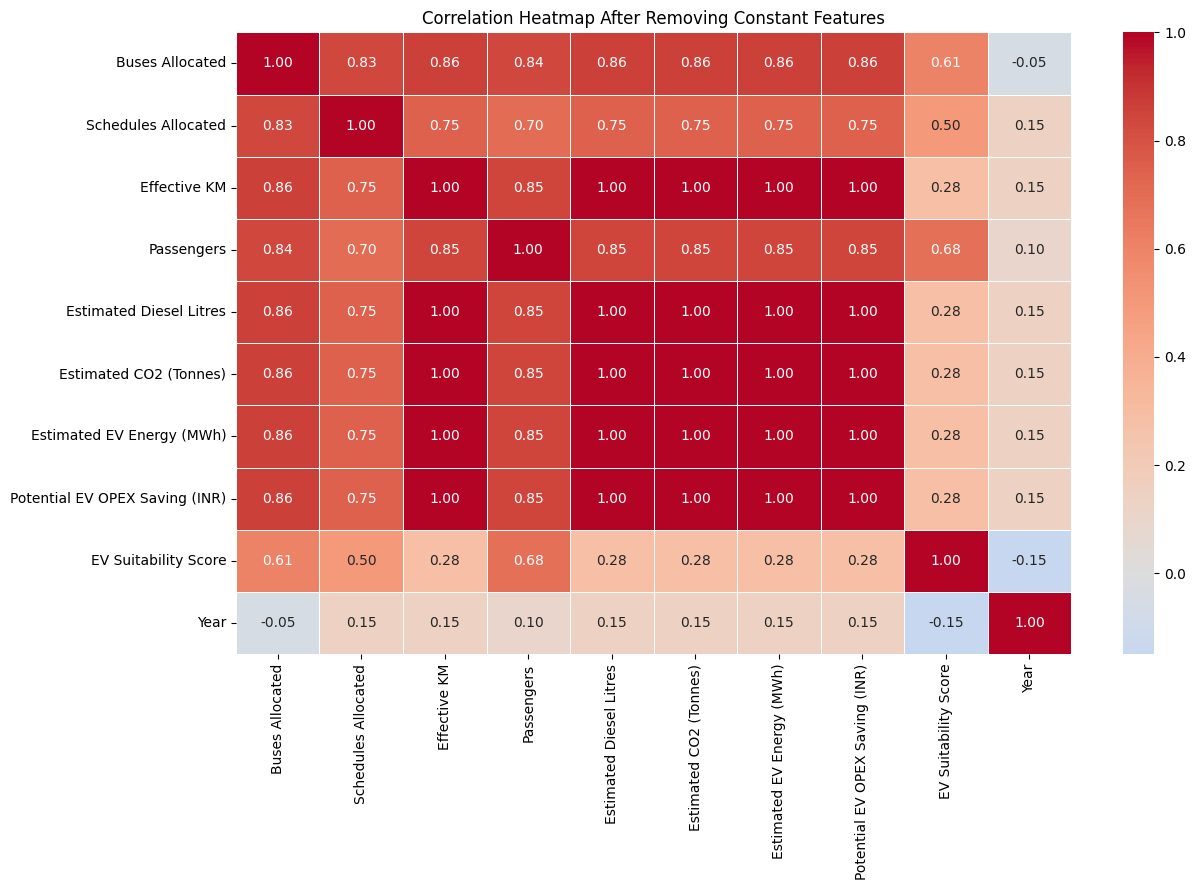

In [35]:
# Removed constant numerical for corelation analysis

constant_columns = [
    col for col in numeric_columns
    if df[col].nunique() <= 1
]

correlation_features = [
    col for col in numeric_columns
    if col not in constant_columns
]

print("Constant columns removed from correlation analysis:")
print(constant_columns)

plt.figure(figsize=(13, 9))

correlation_matrix = df[correlation_features].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title('Correlation Heatmap After Removing Constant Features')
plt.tight_layout()
plt.show()

##Feature Engineering

In [36]:
model_df = df.copy()

# Extract month number from Month
model_df['Month_Number'] = model_df['Month'].dt.month

display(model_df[['Month', 'Year', 'Month_Number']].head(10))

,Month,Year,Month_Number
0,2021-04-01,2021,4
1,2021-05-01,2021,5
2,2021-06-01,2021,6
3,2021-07-01,2021,7
4,2021-08-01,2021,8
5,2021-09-01,2021,9
6,2021-10-01,2021,10
7,2021-11-01,2021,11
8,2021-12-01,2021,12
9,2022-01-01,2022,1


In [37]:
print("Unique Month Numbers:")
print(sorted(model_df['Month_Number'].unique()))

print("\nFeature Engineering completed.")

Unique Month Numbers:
[np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]

Feature Engineering completed.


In [38]:
#passenger per bus

model_df['Passengers_per_Bus'] = (
    model_df['Passengers'] / model_df['Buses Allocated']
)

In [39]:
print(model_df['Passengers_per_Bus'].describe())

count     5520.000000
mean      9339.118811
std       2081.655746
min       3753.061224
25%       8229.817595
50%       9383.613662
75%       9743.868578
max      15156.586207
Name: Passengers_per_Bus, dtype: float64


Feature engineering was performed to extract useful information from the date variable. Month Number was extracted from the Month field to represent monthly patterns. Passengers per Bus was also derived to represent passenger utilization relative to the allocated fleet. Only meaningful features were engineered to avoid unnecessary complexity.

##Feature Selection

In [40]:
# FEATURE SELECTION - STEP 1
# Create modelling dataset from the feature-engineered data

model_df = model_df.copy()

print("Modelling dataset shape:", model_df.shape)

print("\nColumns:")
for col in model_df.columns:
    print("-", col)

Modelling dataset shape: (5520, 22)

Columns:
- Depot ID
- Depot Name
- District
- Month
- Buses Allocated
- Schedules Allocated
- Effective KM
- Passengers
- Estimated Diesel Litres
- Estimated CO2 (Tonnes)
- Diesel Cost (INR/KM)
- EV Cost (INR/KM)
- Estimated EV Energy (MWh)
- Potential EV OPEX Saving (INR)
- EV Battery Capacity (kWh)
- EV Range (KM)
- Charging Power (kW)
- Electricity Tariff (INR/kWh)
- EV Suitability Score
- Year
- Month_Number
- Passengers_per_Bus


In [41]:
# FEATURE SELECTION - STEP 2
# Identify features with no variation

constant_features = [
    col for col in model_df.columns
    if model_df[col].nunique() <= 1
]

print("Constant features:")
for col in constant_features:
    print("-", col)

print("\nNumber of constant features:", len(constant_features))

Constant features:
- Diesel Cost (INR/KM)
- EV Cost (INR/KM)
- EV Battery Capacity (kWh)
- EV Range (KM)
- Charging Power (kW)
- Electricity Tariff (INR/kWh)

Number of constant features: 6


In [42]:
# FEATURE SELECTION - STEP 3
# Remove constant features from the modelling dataset

model_df = model_df.drop(columns=constant_features)

print("Removed constant features:")
for col in constant_features:
    print("-", col)

print("\nNew shape:", model_df.shape)

Removed constant features:
- Diesel Cost (INR/KM)
- EV Cost (INR/KM)
- EV Battery Capacity (kWh)
- EV Range (KM)
- Charging Power (kW)
- Electricity Tariff (INR/kWh)

New shape: (5520, 16)


In [43]:
# FEATURE SELECTION - STEP 4
# Check whether Depot ID and Depot Name contain duplicate information

depot_mapping = model_df.groupby("Depot ID")["Depot Name"].nunique()

print("Depot IDs with more than one Depot Name:",
      (depot_mapping > 1).sum())

print("Unique Depot IDs:", model_df["Depot ID"].nunique())
print("Unique Depot Names:", model_df["Depot Name"].nunique())

Depot IDs with more than one Depot Name: 0
Unique Depot IDs: 92
Unique Depot Names: 92


In [44]:
# FEATURE SELECTION - STEP 6
# Remove raw Month column after extracting Month_Number

model_df = model_df.drop(columns=["Month"])

print("Removed: Month")
print("Month_Number retained")
print("New shape:", model_df.shape)

Removed: Month
Month_Number retained
New shape: (5520, 15)


In [45]:
# FEATURE SELECTION - STEP 7
# Check highly correlated numeric predictors

numeric_features = model_df.select_dtypes(include="number").columns

corr_matrix = model_df[numeric_features].corr()

high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        corr_value = corr_matrix.iloc[i, j]

        if abs(corr_value) >= 0.90:
            high_corr_pairs.append(
                (corr_matrix.columns[i], corr_matrix.columns[j], corr_value)
            )

print("Highly correlated predictor pairs (|r| >= 0.90):")

for col1, col2, corr in high_corr_pairs:
    print(f"{col1} <-> {col2}: {corr:.3f}")

print("\nNumber of highly correlated pairs:", len(high_corr_pairs))

Highly correlated predictor pairs (|r| >= 0.90):
Effective KM <-> Estimated Diesel Litres: 1.000
Effective KM <-> Estimated CO2 (Tonnes): 1.000
Effective KM <-> Estimated EV Energy (MWh): 1.000
Effective KM <-> Potential EV OPEX Saving (INR): 1.000
Estimated Diesel Litres <-> Estimated CO2 (Tonnes): 1.000
Estimated Diesel Litres <-> Estimated EV Energy (MWh): 1.000
Estimated Diesel Litres <-> Potential EV OPEX Saving (INR): 1.000
Estimated CO2 (Tonnes) <-> Estimated EV Energy (MWh): 1.000
Estimated CO2 (Tonnes) <-> Potential EV OPEX Saving (INR): 1.000
Estimated EV Energy (MWh) <-> Potential EV OPEX Saving (INR): 1.000

Number of highly correlated pairs: 10


### Multicollinearity Check

A correlation threshold of |r| ≥ 0.90 was used to identify highly correlated numerical predictors.

Several operational variables showed perfect correlation because they are derived from the same underlying operational quantity, Effective KM.

These relationships were identified and documented during feature selection. The variables were retained at this stage because the exact construction of the EV Suitability Score target is not available, and removing potentially relevant predictors before modelling could affect the analysis.

Model-specific feature reduction can be considered during model development if required.

In [46]:
# Separate features and target
# Depot Name is retained in model_df for final reporting,
# but excluded from ML features because it is an identifier.

X = model_df.drop(columns=["EV Suitability Score", "Depot Name"])
y = model_df["EV Suitability Score"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget column:")
print("EV Suitability Score")

print("\nFeatures:")
for col in X.columns:
    print("-", col)

X shape: (5520, 13)
y shape: (5520,)

Target column:
EV Suitability Score

Features:
- Depot ID
- District
- Buses Allocated
- Schedules Allocated
- Effective KM
- Passengers
- Estimated Diesel Litres
- Estimated CO2 (Tonnes)
- Estimated EV Energy (MWh)
- Potential EV OPEX Saving (INR)
- Year
- Month_Number
- Passengers_per_Bus


In [47]:
# FEATURE SELECTION - STEP 9
# Check data types of predictor variables

print(X.dtypes)

Depot ID                           object
District                           object
Buses Allocated                     int64
Schedules Allocated                 int64
Effective KM                        int64
Passengers                          int64
Estimated Diesel Litres           float64
Estimated CO2 (Tonnes)            float64
Estimated EV Energy (MWh)           int64
Potential EV OPEX Saving (INR)      int64
Year                                int64
Month_Number                        int32
Passengers_per_Bus                float64
dtype: object


In [48]:
# FEATURE SELECTION - STEP 10
# Check categorical feature cardinality

print("Unique Depot IDs:", X["Depot ID"].nunique())
print("Unique Districts:", X["District"].nunique())

print("\nDistricts:")
print(X["District"].unique())

Unique Depot IDs: 92
Unique Districts: 14

Districts:
['Pathanamthitta' 'Alappuzha' 'Ernakulam' 'Thiruvananthapuram' 'Kollam'
 'Thrissur' 'Kottayam' 'Idukki' 'Palakkad' 'Wayanad' 'Kasaragod' 'Kannur'
 'Kozhikode' 'Malappuram']


In [49]:
# FEATURE SELECTION / PREPROCESSING - STEP 11
# One-hot encode categorical features

X_encoded = pd.get_dummies(
    X,
    columns=["Depot ID", "District"],
    drop_first=True
)

print("Original X shape:", X.shape)
print("Encoded X shape:", X_encoded.shape)

print("\nFirst 10 encoded columns:")
print(X_encoded.columns[:10].tolist())

Original X shape: (5520, 13)
Encoded X shape: (5520, 115)

First 10 encoded columns:
['Buses Allocated', 'Schedules Allocated', 'Effective KM', 'Passengers', 'Estimated Diesel Litres', 'Estimated CO2 (Tonnes)', 'Estimated EV Energy (MWh)', 'Potential EV OPEX Saving (INR)', 'Year', 'Month_Number']


In [50]:
# PREPROCESSING - STEP 12
# Validate encoded dataset

print("Data types after encoding:")
print(X_encoded.dtypes.value_counts())

print("\nMissing values after encoding:")
print(X_encoded.isnull().sum().sum())

print("\nFinal encoded shape:")
print(X_encoded.shape)

Data types after encoding:
bool       104
int64        7
float64      3
int32        1
Name: count, dtype: int64

Missing values after encoding:
0

Final encoded shape:
(5520, 115)


In [51]:
# PREPROCESSING - STEP 13
# Split data before scaling to avoid data leakage

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X_encoded,y,test_size=0.20,random_state=42)

numeric_columns = X.select_dtypes(include=["int64", "int32", "float64"]).columns.tolist()

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_columns] = scaler.fit_transform(X_train[numeric_columns])

X_test_scaled[numeric_columns] = scaler.transform(X_test[numeric_columns])

print("Training set:", X_train_scaled.shape)
print("Testing set:", X_test_scaled.shape)
print("Numerical features scaled:", len(numeric_columns))

Training set: (4416, 115)
Testing set: (1104, 115)
Numerical features scaled: 11


In [52]:
# REVIEW 2 - FINAL PREPROCESSING CHECK

print("FINAL PREPROCESSING CHECK")

print("\nTraining data:")
print("Shape:", X_train_scaled.shape)
print("Missing values:", X_train_scaled.isnull().sum().sum())

print("\nTesting data:")
print("Shape:", X_test_scaled.shape)
print("Missing values:", X_test_scaled.isnull().sum().sum())

print("\nTarget:")
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

print("\nAll checks completed.")

FINAL PREPROCESSING CHECK

Training data:
Shape: (4416, 115)
Missing values: 0

Testing data:
Shape: (1104, 115)
Missing values: 0

Target:
Training target: (4416,)
Testing target: (1104,)

All checks completed.


## Final Preprocessed Dataset Export

The final preprocessed dataset is saved for use in the modelling stage of Review 3. This ensures that the preprocessing completed in Review 2 can be consistently reused without modifying the original raw dataset.

In [55]:
# REVIEW 2 - EXPORT FINAL PREPROCESSED DATASET

# Combine final encoded features with target
processed_df = X_encoded.copy()
processed_df["EV Suitability Score"] = y.values

# Save final ML dataset
processed_path = "../data/processed/TEJAS_PREPROCESSED.csv"

processed_df.to_csv(processed_path, index=False)

print("Final preprocessed dataset saved successfully.")
print("File:", processed_path)
print("Shape:", processed_df.shape)

Final preprocessed dataset saved successfully.
File: ../data/processed/TEJAS_PREPROCESSED.csv
Shape: (5520, 116)


In [54]:
# CHECK FINAL REVIEW 2 DATA

print("X shape:", X.shape)
print("X_encoded shape:", X_encoded.shape)
print("y shape:", y.shape)

print("\nEncoded feature columns:")
print(X_encoded.columns.tolist())

X shape: (5520, 13)
X_encoded shape: (5520, 115)
y shape: (5520,)

Encoded feature columns:
['Buses Allocated', 'Schedules Allocated', 'Effective KM', 'Passengers', 'Estimated Diesel Litres', 'Estimated CO2 (Tonnes)', 'Estimated EV Energy (MWh)', 'Potential EV OPEX Saving (INR)', 'Year', 'Month_Number', 'Passengers_per_Bus', 'Depot ID_KSRTC-002', 'Depot ID_KSRTC-003', 'Depot ID_KSRTC-004', 'Depot ID_KSRTC-005', 'Depot ID_KSRTC-006', 'Depot ID_KSRTC-007', 'Depot ID_KSRTC-008', 'Depot ID_KSRTC-009', 'Depot ID_KSRTC-010', 'Depot ID_KSRTC-011', 'Depot ID_KSRTC-012', 'Depot ID_KSRTC-013', 'Depot ID_KSRTC-014', 'Depot ID_KSRTC-015', 'Depot ID_KSRTC-016', 'Depot ID_KSRTC-017', 'Depot ID_KSRTC-018', 'Depot ID_KSRTC-019', 'Depot ID_KSRTC-020', 'Depot ID_KSRTC-021', 'Depot ID_KSRTC-022', 'Depot ID_KSRTC-023', 'Depot ID_KSRTC-024', 'Depot ID_KSRTC-025', 'Depot ID_KSRTC-026', 'Depot ID_KSRTC-027', 'Depot ID_KSRTC-028', 'Depot ID_KSRTC-029', 'Depot ID_KSRTC-030', 'Depot ID_KSRTC-031', 'Depot ID_KSR